In [1]:
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/train.csv
/kaggle/input/train.csv.zip
/kaggle/input/sample_submission.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv
/kaggle/input/test.csv.zip
/kaggle/input/description.md
/kaggle/input/ventilator-pressure-prediction/train.csv
/kaggle/input/ventilator-pressure-prediction/train.csv.zip
/kaggle/input/ventilator-pressure-prediction/sample_submission.csv
/kaggle/input/ventilator-pressure-prediction/sample_submission.csv.zip
/kaggle/input/ventilator-pressure-prediction/test.csv
/kaggle/input/ventilator-pressure-prediction/test.csv.zip
/kaggle/input/ventilator-pressure-prediction/description.md


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
import warnings

warnings.filterwarnings("ignore")
import plotly.express as px



In [3]:
data = pd.read_csv("../input/ventilator-pressure-prediction/train.csv")
data.head()



,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,85053,5,10,0.000000,4.174419,0,6.118700
1,2,85053,5,10,0.033812,7.050149,0,5.907794
2,3,85053,5,10,0.067497,7.564931,0,7.313837
3,4,85053,5,10,0.101394,8.103306,0,8.227765
4,5,85053,5,10,0.135344,8.502619,0,9.422901


In [4]:
data.shape



(5432400, 8)

In [5]:
data.isnull().sum()



id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

In [6]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5432400 entries, 0 to 5432399
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 331.6 MB


In [7]:
data.describe()



,id,breath_id,R,C,time_step,u_in,u_out,pressure
count,5.432400e+06,5.432400e+06,5.432400e+06,5.432400e+06,5.432400e+06,5.432400e+06,5.432400e+06,5.432400e+06
mean,2.716200e+06,6.278936e+04,2.702187e+01,2.608689e+01,1.307171e+00,7.321888e+00,6.204400e-01,1.121807e+01
std,1.568199e+06,3.633651e+04,1.959373e+01,1.714967e+01,7.659424e-01,1.343009e+01,4.852775e-01,8.106474e+00
min,1.000000e+00,1.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-1.895744e+00
25%,1.358101e+06,3.133000e+04,5.000000e+00,1.000000e+01,6.428902e-01,3.964440e-01,0.000000e+00,6.329607e+00
50%,2.716200e+06,6.270000e+04,2.000000e+01,2.000000e+01,1.308093e+00,4.387377e+00,1.000000e+00,7.032628e+00
75%,4.074300e+06,9.426000e+04,5.000000e+01,5.000000e+01,1.965460e+00,4.983969e+00,1.000000e+00,1.364103e+01
max,5.432400e+06,1.257490e+05,5.000000e+01,5.000000e+01,2.937238e+00,1.000000e+02,1.000000e+00,6.482099e+01


<Axes: >

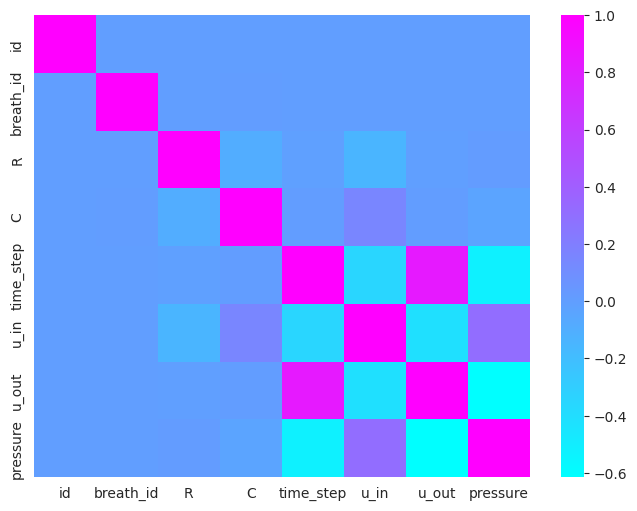

In [8]:
plt.figure(figsize=(8, 6))
# Bugfix: pandas 2.x warns on non-numeric correlations; restrict to numeric columns for stability.
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), cmap="cool")



In [9]:
cat_col = []
num_col = []
for i in data.columns:
    if data[i].value_counts().count() > 10:
        num_col.append(i)
    else:
        cat_col.append(i)
print(f"categorical columns: {cat_col}")
print(f"numerical columns: {num_col}")



categorical columns: ['R', 'C', 'u_out']
numerical columns: ['id', 'breath_id', 'time_step', 'u_in', 'pressure']


Text(0.5, 0.98, 'Countplot of Categorical Data')

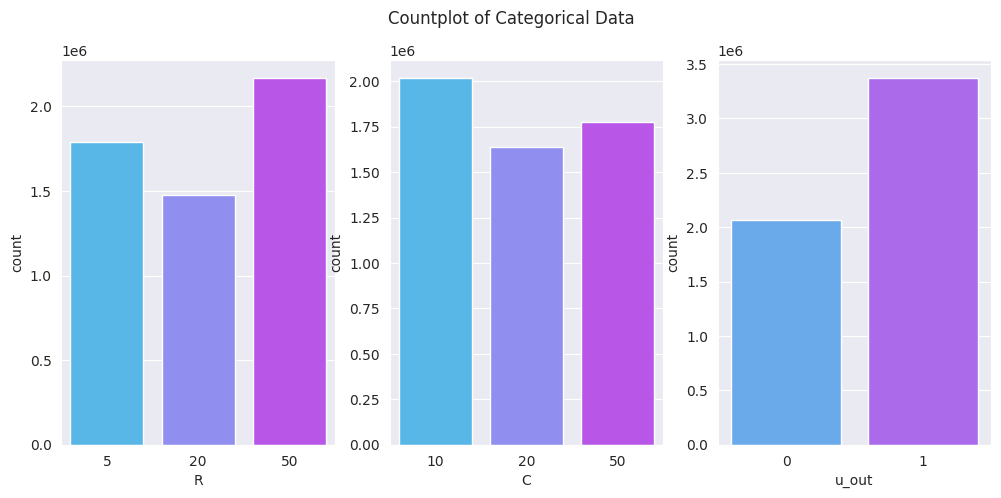

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
j = 0
for i in cat_col:
    # Bugfix: seaborn API expects x=... for newer versions
    sns.countplot(x=data[i], palette="cool", ax=ax[j])
    j += 1
fig.suptitle("Countplot of Categorical Data")



In [11]:
num_col = num_col[2:]
num_col



['time_step', 'u_in', 'pressure']

Text(0.5, 0.98, 'Histplot of Numerical Data')

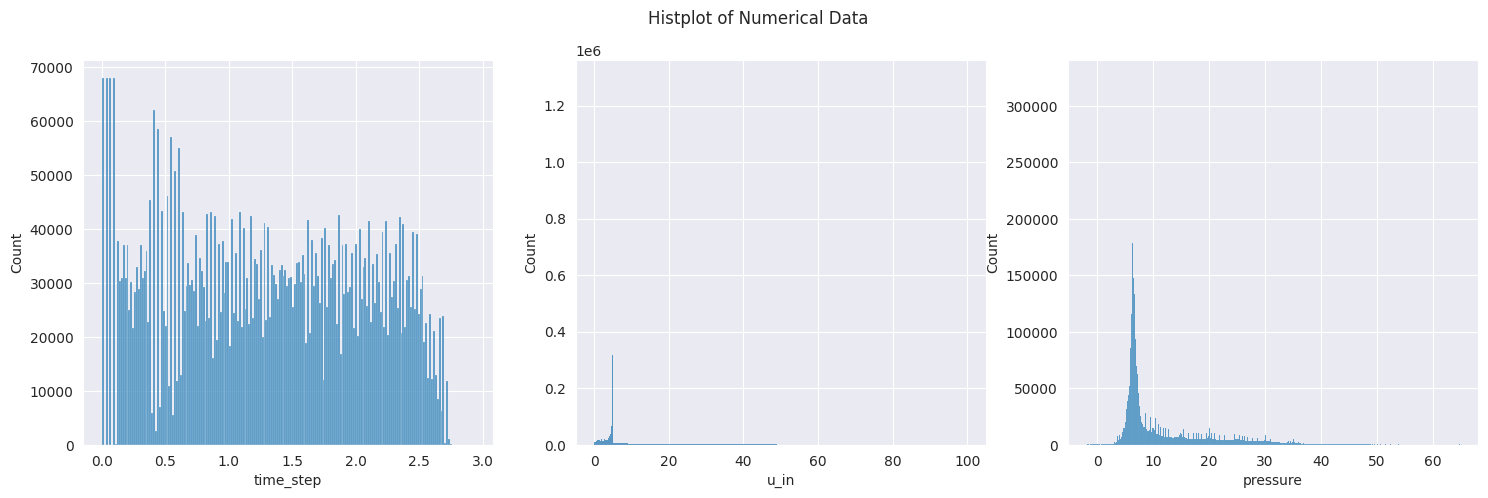

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
j = 0
for i in num_col:
    sns.histplot(data[i], ax=ax[j])
    j += 1
fig.suptitle("Histplot of Numerical Data")



Text(0.5, 0.98, 'Boxplot of Numerical Data')

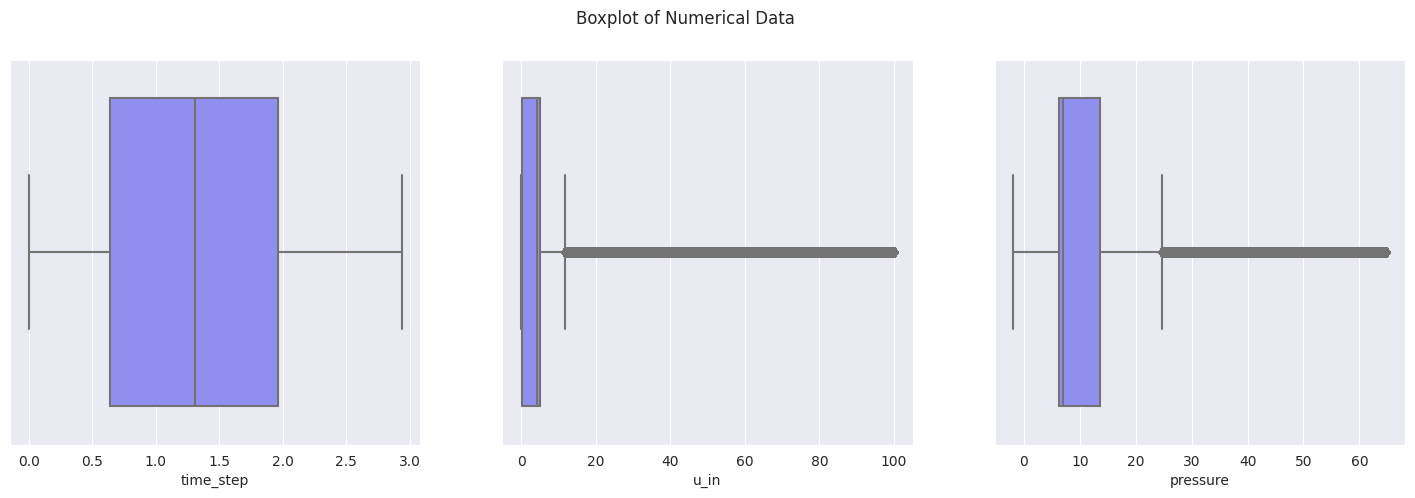

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
j = 0
for i in num_col:
    # Bugfix: seaborn boxplot API expects x=... for newer versions
    sns.boxplot(x=data[i], ax=ax[j], palette="cool")
    j += 1
fig.suptitle("Boxplot of Numerical Data")



In [14]:
train = data.copy()



<Axes: xlabel='u_in'>

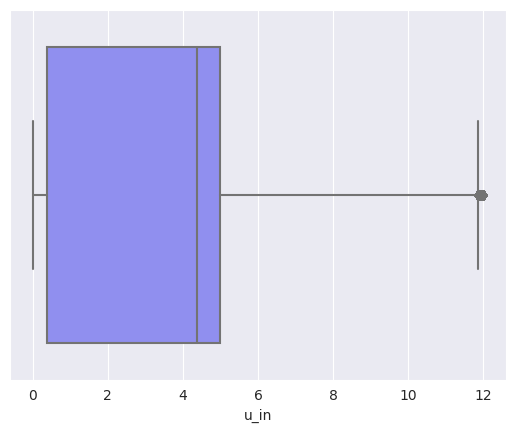

In [15]:
train["u_in"] = np.where(train["u_in"] > 12, train["u_in"].mean(), train["u_in"])
sns.boxplot(x=train["u_in"], palette="cool")



<Axes: xlabel='pressure'>

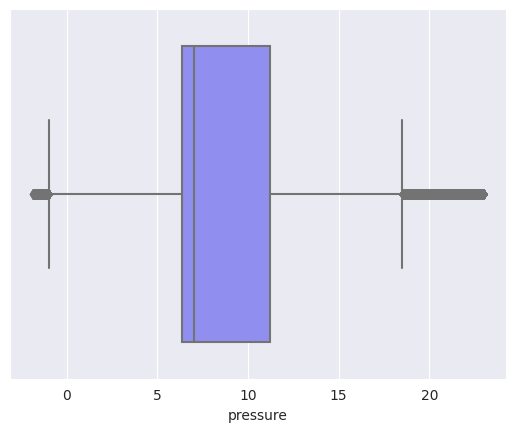

In [16]:
train["pressure"] = np.where(
    train["pressure"] > 23, train["pressure"].mean(), train["pressure"]
)
sns.boxplot(x=train["pressure"], palette="cool")



In [17]:
X_train = train.drop("pressure", axis=1)
y_train = train["pressure"]



In [18]:
from xgboost import XGBRegressor

# Bugfix: Kaggle/CPU environments may not expose a GPU; GPU params crash with "Must have at least one device".
# Keep the same core model/params, just switch to CPU-safe tree_method/predictor and remove gpu_id.
xgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.1,
    "subsample": 0.95,
    "colsample_bytree": 0.11,
    "max_depth": 2,
    "booster": "gbtree",
    "reg_lambda": 66.1,
    "reg_alpha": 15.9,
    "random_state": 42,
    "tree_method": "hist",
    "predictor": "auto",
}

model = XGBRegressor(**xgb_params)

# Note: Training on full 5.4M rows can be heavy but is required by the original approach.
model.fit(X_train, y_train)



XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.11, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5000, n_jobs=None,
             num_parallel_tree=None, predictor='auto', ...)

In [19]:
test_data = pd.read_csv("../input/ventilator-pressure-prediction/test.csv")

# Bugfix: ensure test columns match training feature columns/order.
X_test = test_data[X_train.columns]
pred = model.predict(X_test)



In [20]:
sample = pd.read_csv("../input/ventilator-pressure-prediction/sample_submission.csv")
sample.head()



,id,pressure
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [21]:
# Bugfix: ensure correct submission schema and alignment.
submission = pd.DataFrame(
    {"id": test_data["id"].values, "pressure": pred.astype(float)}
)
submission.to_csv("submission.csv", index=False)

# Optional sanity checks (do not affect output)
print(submission.head())
print("Saved submission.csv with shape:", submission.shape)

   id   pressure
0   1   4.497682
1   2   4.009602
2   3   8.434254
3   4  10.872084
4   5  11.286249
Saved submission.csv with shape: (603600, 2)
